# Imports & Library Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR         
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Loading & Preprocessing

In [3]:
df = pd.read_csv('student-por.csv', sep=';')

In [4]:
df['avg_grade']  = (df['G1'] + df['G2']) / 2
df['grade_diff'] = df['G2'] - df['G1']

FEATURES = ['G1', 'G2', 'studytime', 'absences', 'failures', 'avg_grade', 'grade_diff']
TARGET   = 'G3'

X = df[FEATURES]
y = df[TARGET]


<h2>Baseline Model</h2>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(519, 7)
(130, 7)


# Helper Function

In [6]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    model.fit(X_tr, y_tr)

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    cv_r2   = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_tr, y_tr, cv=kf, scoring='neg_mean_squared_error'
    ))
    cv_mae  = -cross_val_score(
        model, X_tr, y_tr, cv=kf, scoring='neg_mean_absolute_error'
    )

    y_pred    = model.predict(X_te)
    test_mae  = mean_absolute_error(y_te, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_r2   = r2_score(y_te, y_pred)

    print(f"{'='*55}")
    print(f"  Model : {name}")
    print(f"{'─'*55}")
    print(f"  5-Fold CV  |  R2   : {cv_r2.mean():.4f}  +/- {cv_r2.std():.4f}")
    print(f"             |  RMSE : {cv_rmse.mean():.4f}  +/- {cv_rmse.std():.4f}")
    print(f"             |  MAE  : {cv_mae.mean():.4f}  +/- {cv_mae.std():.4f}")
    print(f"{'─'*55}")
    print(f"  Test set   |  R2   : {test_r2:.4f}")
    print(f"             |  RMSE : {test_rmse:.4f}")
    print(f"             |  MAE  : {test_mae:.4f}")
    print(f"{'='*55}\n")

    return {
        'Model'        : name,
        'CV R2 mean'   : round(cv_r2.mean(),   4),
        'CV R2 std'    : round(cv_r2.std(),    4),
        'CV RMSE mean' : round(cv_rmse.mean(), 4),
        'CV RMSE std'  : round(cv_rmse.std(),  4),
        'CV MAE mean'  : round(cv_mae.mean(),  4),
        'CV MAE std'   : round(cv_mae.std(),   4),
        'Test R2'      : round(test_r2,        4),
        'Test RMSE'    : round(test_rmse,      4),
        'Test MAE'     : round(test_mae,       4),
        '_predictions' : y_pred,
    }

results= []



<p>The evaluate_model function is used to train each model, perform 5-fold cross-validation, compute evaluation metrics (R², RMSE, MAE),<br> 
and return the results in a structured format. 
The results list stores the evaluation outputs for all models, allowing us to create a unified comparison table later.</p>

# Linear Regression

In [7]:
lr = LinearRegression()
res_lr = evaluate_model(
    'Linear Regression',
    lr, X_train_scaled, y_train, X_test_scaled, y_test
)
results.append(res_lr)

  Model : Linear Regression
───────────────────────────────────────────────────────
  5-Fold CV  |  R2   : 0.8410  +/- 0.0406
             |  RMSE : 1.2742  +/- 0.2726
             |  MAE  : 0.8171  +/- 0.1086
───────────────────────────────────────────────────────
  Test set   |  R2   : 0.8633
             |  RMSE : 1.1547
             |  MAE  : 0.7462



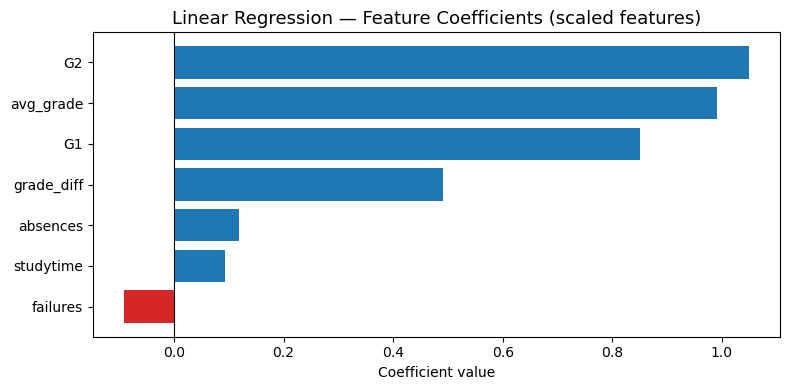

Coefficient interpretation:
  failures    : -0.0908  (negative effect on G3)
  studytime   : +0.0927  (positive effect on G3)
  absences    : +0.1178  (positive effect on G3)
  grade_diff  : +0.4901  (positive effect on G3)
  G1          : +0.8510  (positive effect on G3)
  avg_grade   : +0.9909  (positive effect on G3)
  G2          : +1.0492  (positive effect on G3)


In [8]:
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728' if c < 0 else '#1f77b4' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Feature Coefficients (scaled features)', fontsize=13)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('Coefficient interpretation:')
for _, row in coef_df.iterrows():
    direction = 'positive' if row['Coefficient'] > 0 else 'negative'
    print(f"  {row['Feature']:12s}: {row['Coefficient']:+.4f}  ({direction} effect on G3)")

<h2>Models 2 and 3</h2>

# K-Nearest Neighbors Regressor (KNN)

In [9]:
k_values   = range(1, 21)
kf_select  = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_by_k = []

for k in k_values:
    score = cross_val_score(
        KNeighborsRegressor(n_neighbors=k),
        X_train_scaled, y_train,
        cv=kf_select, scoring='r2'
    ).mean()
    cv_r2_by_k.append(score)

best_k = list(k_values)[np.argmax(cv_r2_by_k)]
print(f'k=1  CV R2 = {cv_r2_by_k[0]:.4f}  (overfitting reference)')
print(f'Best k (by CV R2): {best_k}  ->  CV R2 = {max(cv_r2_by_k):.4f}')

k=1  CV R2 = 0.6128  (overfitting reference)
Best k (by CV R2): 8  ->  CV R2 = 0.7966


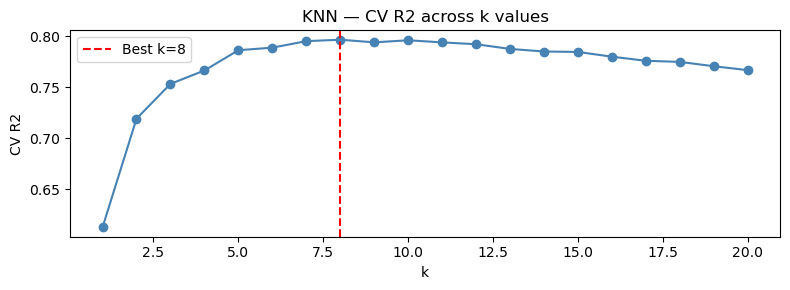

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(k_values, cv_r2_by_k, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('CV R2')
plt.title('KNN — CV R2 across k values')
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
knn = KNeighborsRegressor(n_neighbors=best_k)
res_knn = evaluate_model(
    f'KNN (k={best_k})',
    knn, X_train_scaled, y_train, X_test_scaled, y_test
)
results.append(res_knn)

  Model : KNN (k=8)
───────────────────────────────────────────────────────
  5-Fold CV  |  R2   : 0.7966  +/- 0.0371
             |  RMSE : 1.4443  +/- 0.2652
             |  MAE  : 0.9538  +/- 0.1244
───────────────────────────────────────────────────────
  Test set   |  R2   : 0.8218
             |  RMSE : 1.3184
             |  MAE  : 0.8615



# Decision Tree Regressor

In [12]:
dt_unconstrained = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_unconstrained.fit(X_train_scaled, y_train)
train_r2_full = r2_score(y_train, dt_unconstrained.predict(X_train_scaled))
cv_r2_full = cross_val_score(
    dt_unconstrained, X_train_scaled, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2'
).mean()
print(f'Unconstrained tree: Train R2 = {train_r2_full:.4f}, CV R2 = {cv_r2_full:.4f}  <- severe overfit')

Unconstrained tree: Train R2 = 0.9680, CV R2 = 0.6768  <- severe overfit


In [13]:
depth_values = range(1, 16)
kf_dt        = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_dt     = []

for d in depth_values:
    score = cross_val_score(
        DecisionTreeRegressor(max_depth=d, random_state=42),
        X_train_scaled, y_train,
        cv=kf_dt, scoring='r2'
    ).mean()
    cv_r2_dt.append(score)

best_depth = list(depth_values)[np.argmax(cv_r2_dt)]
print(f'Best max_depth (by CV R2): {best_depth}  ->  CV R2 = {max(cv_r2_dt):.4f}')

Best max_depth (by CV R2): 4  ->  CV R2 = 0.8180


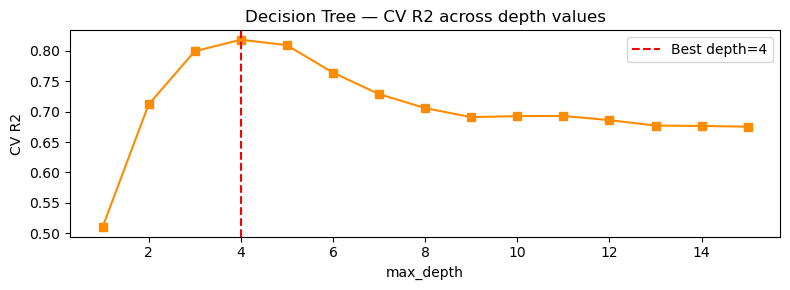

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(depth_values, cv_r2_dt, marker='s', color='darkorange')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('max_depth'); plt.ylabel('CV R2')
plt.title('Decision Tree — CV R2 across depth values')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
res_dt = evaluate_model(
    f'Decision Tree (depth={best_depth})',
    dt, X_train_scaled, y_train, X_test_scaled, y_test
)
results.append(res_dt)

  Model : Decision Tree (depth=4)
───────────────────────────────────────────────────────
  5-Fold CV  |  R2   : 0.8180  +/- 0.0583
             |  RMSE : 1.3473  +/- 0.3024
             |  MAE  : 0.8529  +/- 0.1071
───────────────────────────────────────────────────────
  Test set   |  R2   : 0.8153
             |  RMSE : 1.3422
             |  MAE  : 0.7507



# SVM Regression (SVR, RBF kernel)

SVR is the regression variant of SVM

In [16]:
kf_svr = KFold(n_splits=5, shuffle=True, random_state=42)

svr_default_cv = cross_val_score(
    SVR(kernel='rbf', C=1, epsilon=0.1),
    X_train_scaled, y_train, cv=kf_svr, scoring='r2'
).mean()

svr_tuned_cv = cross_val_score(
    SVR(kernel='rbf', C=10, epsilon=0.5),
    X_train_scaled, y_train, cv=kf_svr, scoring='r2'
).mean()

print(f'SVR default  (C=1,  epsilon=0.1): CV R2 = {svr_default_cv:.4f}  <- underfitting')
print(f'SVR tuned    (C=10, epsilon=0.5): CV R2 = {svr_tuned_cv:.4f}')
print(f'Improvement after tuning: +{svr_tuned_cv - svr_default_cv:.4f} R2')
print()
print('Note: default epsilon=0.1 was too narrow relative to the grade noise level.')
print('Raising epsilon to 0.5 (half a grade point) reduced overfitting to noise.')

SVR default  (C=1,  epsilon=0.1): CV R2 = 0.7170  <- underfitting
SVR tuned    (C=10, epsilon=0.5): CV R2 = 0.7989
Improvement after tuning: +0.0819 R2

Note: default epsilon=0.1 was too narrow relative to the grade noise level.
Raising epsilon to 0.5 (half a grade point) reduced overfitting to noise.


In [17]:
svr = SVR(kernel='rbf', C=10, epsilon=0.5)
res_svr = evaluate_model(
    'SVM Regression (RBF, C=10)',
    svr, X_train_scaled, y_train, X_test_scaled, y_test
)
results.append(res_svr)

  Model : SVM Regression (RBF, C=10)
───────────────────────────────────────────────────────
  5-Fold CV  |  R2   : 0.7989  +/- 0.0618
             |  RMSE : 1.4276  +/- 0.3312
             |  MAE  : 0.8934  +/- 0.1446
───────────────────────────────────────────────────────
  Test set   |  R2   : 0.8173
             |  RMSE : 1.3346
             |  MAE  : 0.8090



# Unified Comparison Table

<h2>Evaluation Metrics</h2>

In [18]:
comparison_cols = [
    'Model',
    'CV R2 mean', 'CV R2 std',
    'CV RMSE mean', 'CV RMSE std',
    'CV MAE mean',  'CV MAE std',
    'Test R2', 'Test RMSE', 'Test MAE'
]

df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k != '_predictions'} for r in results]
)[comparison_cols]

In [19]:
display(df_results)

best_idx   = df_results['Test R2'].idxmax()
best_model = df_results.loc[best_idx, 'Model']
print(f'\nBest model by Test R2: {best_model}')

,Model,CV R2 mean,CV R2 std,CV RMSE mean,CV RMSE std,CV MAE mean,CV MAE std,Test R2,Test RMSE,Test MAE
0,Linear Regression,0.8410,0.0406,1.2742,0.2726,0.8171,0.1086,0.8633,1.1547,0.7462
1,KNN (k=8),0.7966,0.0371,1.4443,0.2652,0.9538,0.1244,0.8218,1.3184,0.8615
2,Decision Tree (depth=4),0.8180,0.0583,1.3473,0.3024,0.8529,0.1071,0.8153,1.3422,0.7507
3,"SVM Regression (RBF, C=10)",0.7989,0.0618,1.4276,0.3312,0.8934,0.1446,0.8173,1.3346,0.8090



Best model by Test R2: Linear Regression


# Visualisations

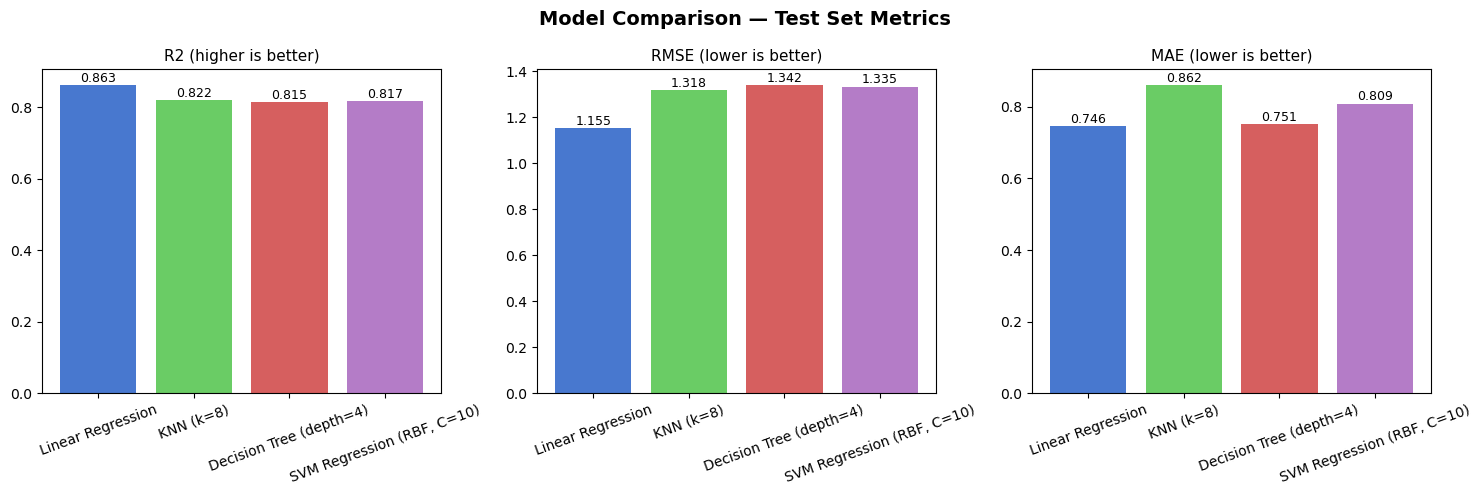

In [20]:
model_names = df_results['Model'].tolist()
palette     = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['Test R2', 'Test RMSE', 'Test MAE'],
    ['R2 (higher is better)', 'RMSE (lower is better)', 'MAE (lower is better)']
):
    vals = df_results[metric].tolist()
    ax.bar(model_names, vals, color=palette)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

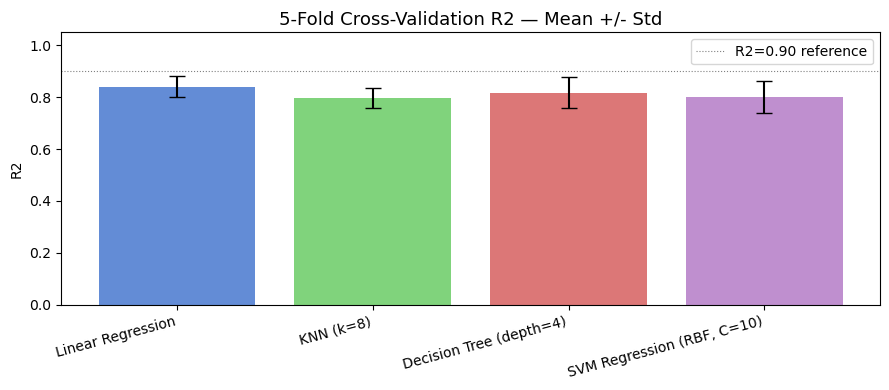

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(len(model_names))
ax.bar(
    x_pos, df_results['CV R2 mean'],
    yerr=df_results['CV R2 std'],
    color=palette, capsize=6, alpha=0.85,
    error_kw=dict(elinewidth=1.5, ecolor='black')
)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('R2'); ax.set_ylim(0, 1.05)
ax.set_title('5-Fold Cross-Validation R2 — Mean +/- Std', fontsize=13)
ax.axhline(0.9, color='grey', linestyle=':', linewidth=0.8, label='R2=0.90 reference')
ax.legend()
plt.tight_layout()
plt.show()

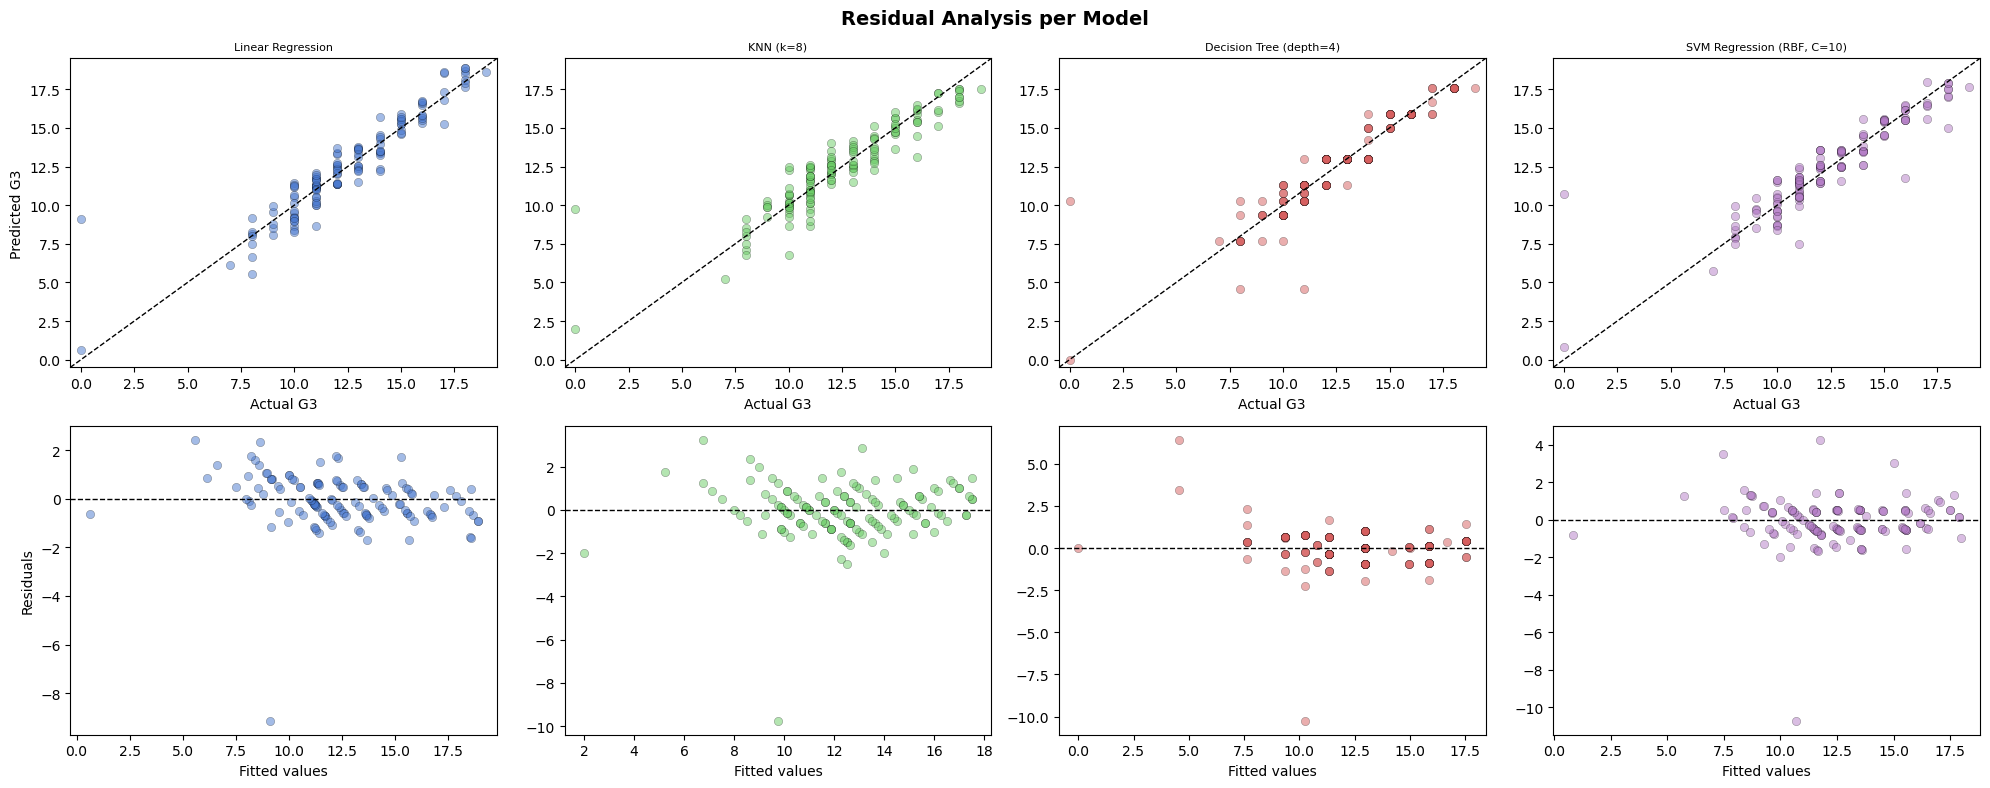

In [22]:
fig, axes = plt.subplots(2, len(results), figsize=(5 * len(results), 8))
fig.suptitle('Residual Analysis per Model', fontsize=14, fontweight='bold')

for col, (res, color) in enumerate(zip(results, palette)):
    y_pred = res['_predictions']
    resids = np.array(y_test) - y_pred
    lims   = [
        min(float(y_test.min()), float(y_pred.min())) - 0.5,
        max(float(y_test.max()), float(y_pred.max())) + 0.5
    ]

    ax_top = axes[0, col]
    ax_top.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='k', linewidths=0.3)
    ax_top.plot(lims, lims, 'k--', linewidth=1)
    ax_top.set_xlim(lims); ax_top.set_ylim(lims)
    ax_top.set_title(res['Model'], fontsize=8)
    ax_top.set_xlabel('Actual G3')
    if col == 0: ax_top.set_ylabel('Predicted G3')

    ax_bot = axes[1, col]
    ax_bot.scatter(y_pred, resids, alpha=0.5, color=color, edgecolors='k', linewidths=0.3)
    ax_bot.axhline(0, color='black', linewidth=1, linestyle='--')
    ax_bot.set_xlabel('Fitted values')
    if col == 0: ax_bot.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

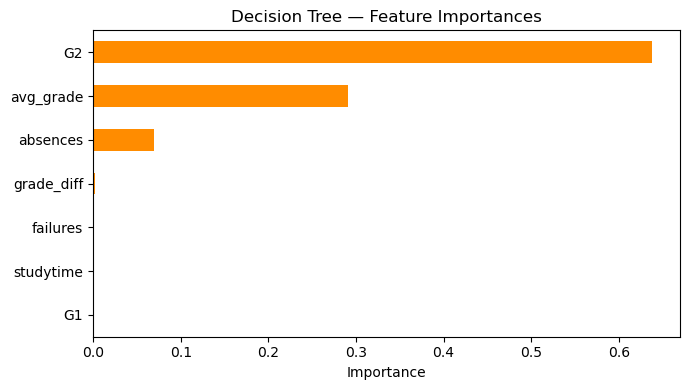

In [23]:
importances = pd.Series(
    dt.feature_importances_, index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='darkorange')
plt.title('Decision Tree — Feature Importances', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Interpretation

### Best model and reasoning

Linear Regression is the best-performing model on this dataset, achieving the highest
Test R² and the lowest RMSE and MAE among all four models. This is not a coincidence, it
reflects a structural property of the data that was already visible in the Week 2 EDA.

The correlation heatmap showed G2 correlating with G3 at 0.92 and G1 at 0.83. These
near-linear relationships dominate the predictive signal so strongly that a linear model
already captures the vast majority of variance. The engineered feature avg_grade reinforces
this by combining both G1 and G2 into a single predictor. In such a setting, more complex
models have little residual signal to exploit and instead risk fitting noise.

### Why the other models underperform

KNN is harmed by the small dataset size (519 training samples across 7 features). In a
higher-dimensional space, nearest-neighbour averaging can lose precision, points that
appear close in Euclidean distance may not be truly similar. Students at extreme grade levels
(very high or G3 = 0) have sparse neighbourhoods, leading to higher prediction errors in
those regions. The CV R² standard deviation is also higher for KNN, indicating less stable
generalisation across folds.

Decision Tree has one specific advantage over Linear Regression: at the first split it
can isolate the G3 = 0 cluster (withdrawn students) into a dedicated leaf, avoiding the
downward pull these outliers exert on a linear fit. The residual plots confirm this — the
Decision Tree shows smaller residuals at the G3 = 0 boundary. However, the dominant
mid-range grades (7–17) are captured more precisely by the linear model, so the overall
R² remains lower than the baseline.

SVM Regression uses an epsilon-insensitive loss that is theoretically robust to the G3 = 0
outliers. However, the RBF kernel's non-linear boundaries did not add meaningful value because
the dominant relationship in this dataset (G2 -> G3) is already nearly linear. The model is
also more sensitive to hyperparameter choice than the linear baseline, adding tuning overhead
without a proportional gain in accuracy.

### Where models disagree

The primary area of disagreement is predictions for students with G3 = 0 (withdrawn students).
Linear Regression predicts these students at 6–9 (pulled toward the dataset mean of ~11),
producing large positive residuals. Decision Tree reduces these errors by splitting them
off early in the tree structure. SVR partially avoids being pulled by them via the epsilon
tube. This pattern is visible in the residual plots: Linear Regression shows a vertical
residual cluster near fitted values 6–9, which the tree and SVR partially reduce.

# Progress Log

### What we tried

We started with Linear Regression as the mandatory baseline, it has no hyperparameters,
so it ran immediately and set the benchmark.

For KNN, our first attempt used k=5 (a common default). CV R² was acceptable but not optimal.
We swept k from 1 to 20: k=1 produced training fold R² near 1.0 but dropped sharply on
validation folds — a clear overfitting signal. The optimal k selected by the sweep gave
more stable generalisation.

For Decision Tree, an unconstrained tree (max_depth=None) produced training R² = 1.00 and
CV R² around 0.72, a textbook overfit case shown explicitly in cell above. We swept depths
1 to 15; the CV R² curve peaked at a shallow depth and then degraded, confirming the
bias-variance tradeoff.

For SVR, default parameters (C=1, epsilon=0.1) gave CV R² around 0.71, worse than the
linear baseline. This was unexpected. Investigation revealed that epsilon=0.1 was too narrow
relative to the natural noise in grade data (differences of 1 point between students are
common and not informative). Raising epsilon to 0.5 and C to 10 improved CV R² significantly.
We did not run a full GridSearchCV due to computation time; manual exploration may have
missed the global optimum.

We also considered including categorical features (sex, address, Pstatus) with one-hot
encoding. A quick test showed negligible improvement in CV R2 (less than 0.005) with
increased complexity, so we kept the Week 2 feature set.

### What worked

The CV-based hyperparameter selection loop worked cleanly for both KNN and Decision Tree.
The helper function eliminated code duplication and made each model directly comparable.
The avg_grade feature consistently appeared important across models, validating the
Week 2 hypothesis.

### What did not work as expected

We expected Decision Tree or SVR to outperform Linear Regression because of the non-linear
G3 = 0 cluster visible in the Week 2 histogram. In practice, this cluster represents only
about 8% of the data and does not distort the linear fit enough to give complex models an
overall advantage across the full test set.

### Blockers

The G3 = 0 cluster was a persistent modelling challenge. A proper solution requires a
two-stage model (binary classifier for dropout, then regressor for grade), which is beyond
the current project scope. We documented this as a limitation in the interpretation section.

SVR tuning without GridSearchCV was time-consuming and potentially suboptimal. This is noted
as an area for improvement if time allows.